# Q2 — Is the Warming Linear or Accelerating?

This notebook addresses whether observed global warming has been linear or accelerating.  
We compare linear trends over two equal-length windows (1970–1997 and 1998–2024), then fit a quadratic to the full 1970–2024 period as an empirical test for curvature.

**Data:** Berkeley Earth Land+Ocean monthly anomalies (relative to 1951–1980 mean), file `data/Land_and_Ocean_complete.txt`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

# ── Load data ──────────────────────────────────────────────────────────────
data_path = "data/Land_and_Ocean_complete.txt"
rows = []
with open(data_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("%") or line == "":
            continue
        parts = line.split()
        if len(parts) >= 4:
            try:
                year  = int(parts[0])
                month = int(parts[1])
                anomaly = float(parts[2])
                unc     = float(parts[3])
                rows.append((year, month, anomaly, unc))
            except ValueError:
                continue

df = pd.DataFrame(rows, columns=["year", "month", "anomaly", "unc"])
# keep only the air-temperature section (before the sea-surface repeat block)
# Berkeley Earth repeats the whole table for the SST-below-ice version.
# The first block ends when year resets to 1850 a second time.
split_idx = df.index[(df["year"] == 1850) & (df["month"] == 1)]
if len(split_idx) > 1:
    df = df.iloc[: split_idx[1]]

print(f"Monthly records: {len(df)},  years {df['year'].min()}–{df['year'].max()}")

Monthly records: 2100,  years 1850–2024


In [3]:
# ── Annual means (require ≥10 months to avoid biasing incomplete years) ────
annual = (
    df.groupby("year")
      .agg(anomaly=("anomaly", "mean"), n=("anomaly", "count"))
      .query("n >= 10")
      .reset_index()
)

# Restrict to our analysis window
annual = annual[(annual["year"] >= 1970) & (annual["year"] <= 2024)].copy()
years = annual["year"].values
T     = annual["anomaly"].values

print(f"Annual means from {years[0]} to {years[-1]} ({len(years)} years)")
print(f"Temperature range: {T.min():.3f} to {T.max():.3f} °C")

Annual means from 1970 to 2024 (55 years)
Temperature range: -0.102 to 1.311 °C


## Period choice justification

We split at **1997 / 1998** for two complementary reasons:

1. **Equal window lengths** — 1970–1997 and 1998–2024 are both 28 years, so any difference in slope cannot be an artefact of differing degrees of freedom.  
2. **Physical event marker** — 1997/1998 hosted the strongest El Niño of the instrumental record, after which a much-debated apparent "hiatus" or slowdown attracted significant literature attention.  Choosing this breakpoint lets us test the claim that the underlying trend changed, while also coinciding with the question's suggested split.

A difference in OLS slopes between the two windows does **not** by itself prove a change in the forced warming rate.  Internal variability (ENSO, PDO, volcanic forcing) can shift a segment's apparent trend substantially — a faster early period followed by a slower late period, or vice versa, can arise from a single linear forced trend riding on top of natural variability.

In [4]:
# ── Linear trend fits for the two windows ─────────────────────────────────
P1_START, P1_END = 1970, 1997
P2_START, P2_END = 1998, 2024

mask1 = (years >= P1_START) & (years <= P1_END)
mask2 = (years >= P2_START) & (years <= P2_END)

def linear_fit(x, y):
    res = stats.linregress(x, y)
    return res  # .slope, .intercept, .stderr (on slope), .rvalue

r1 = linear_fit(years[mask1], T[mask1])
r2 = linear_fit(years[mask2], T[mask2])

# 95 % confidence intervals on the slope (t-distribution, df = n-2)
from scipy.stats import t as t_dist

def ci95_slope(res, n):
    t_crit = t_dist.ppf(0.975, df=n - 2)
    return t_crit * res.stderr

n1 = mask1.sum()
n2 = mask2.sum()
ci1 = ci95_slope(r1, n1)
ci2 = ci95_slope(r2, n2)

print(f"Period 1 ({P1_START}–{P1_END}, n={n1})")
print(f"  Slope = {r1.slope*10:.4f} ± {ci1*10:.4f} °C / decade  (R² = {r1.rvalue**2:.3f})")
print()
print(f"Period 2 ({P2_START}–{P2_END}, n={n2})")
print(f"  Slope = {r2.slope*10:.4f} ± {ci2*10:.4f} °C / decade  (R² = {r2.rvalue**2:.3f})")

Period 1 (1970–1997, n=28)
  Slope = 0.1852 ± 0.0482 °C / decade  (R² = 0.706)

Period 2 (1998–2024, n=27)
  Slope = 0.2403 ± 0.0546 °C / decade  (R² = 0.767)


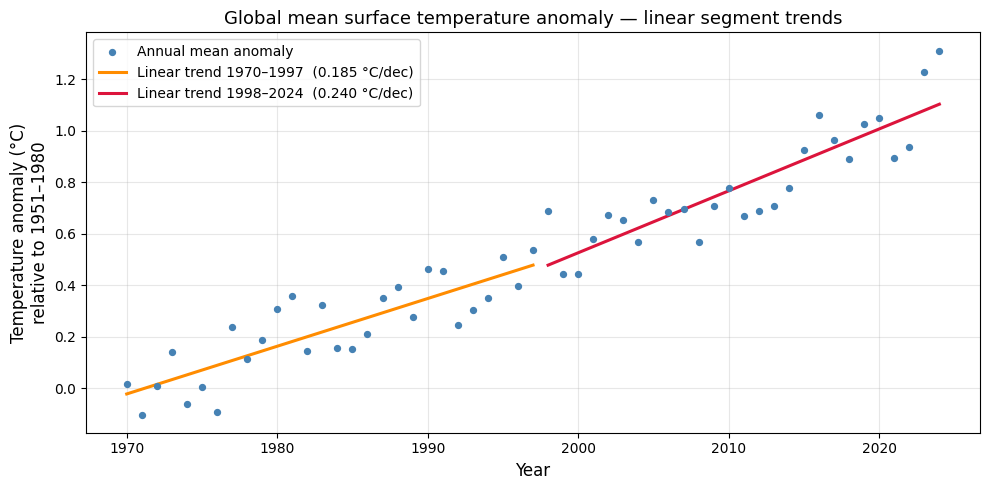

In [5]:
# ── Figure 1 — annual anomalies + two linear segment fits ─────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(years, T, s=18, color="steelblue", zorder=3, label="Annual mean anomaly")

for mask, res, label, color in [
    (mask1, r1, f"Linear trend {P1_START}–{P1_END}  ({r1.slope*10:.3f} °C/dec)", "darkorange"),
    (mask2, r2, f"Linear trend {P2_START}–{P2_END}  ({r2.slope*10:.3f} °C/dec)", "crimson"),
]:
    x_seg = years[mask]
    y_fit = res.slope * x_seg + res.intercept
    ax.plot(x_seg, y_fit, lw=2.2, color=color, label=label)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Temperature anomaly (°C)\nrelative to 1951–1980", fontsize=12)
ax.set_title("Global mean surface temperature anomaly — linear segment trends", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Q2_linear_segments.png", dpi=150)
plt.show()

In [6]:
# ── Quadratic fit over 1970–2024 ──────────────────────────────────────────
# Centre the time axis at the midpoint to reduce collinearity
t0 = (years[0] + years[-1]) / 2          # = 1997.0
t_c = years - t0                          # centred year

# np.polyfit with cov=True uses least-squares + residual variance to give
# the full covariance matrix of [a, b, c] in  T = a*t^2 + b*t + c
coeffs, cov_matrix = np.polyfit(t_c, T, deg=2, cov=True)
a, b, c = coeffs
a_err = np.sqrt(cov_matrix[0, 0])        # 1-sigma uncertainty on a

# Acceleration = d²T/dt² = 2a   (°C yr⁻²)
acceleration     = 2 * a
acceleration_err = 2 * a_err             # 1-sigma; multiply by 1.96 for 95 %

# Rate at the midpoint = b  (°C yr⁻¹)
rate_mid = b
rate_mid_err = np.sqrt(cov_matrix[1, 1])

print(f"Quadratic fit  T(t) = a·(t−{t0:.0f})² + b·(t−{t0:.0f}) + c")
print(f"  a  = {a:.6f}  ±  {a_err:.6f}  °C yr⁻²")
print(f"  b  = {b:.4f}  ±  {rate_mid_err:.4f}  °C yr⁻¹  (rate at {t0:.0f})")
print(f"  c  = {c:.4f}  °C  (value at {t0:.0f})")
print()
print(f"Acceleration (2a) = {acceleration*100:.4f} ± {acceleration_err*1.96*100:.4f}  °C per century per year  [95 % CI]")
print(f"                  = {acceleration*10:.5f} ± {acceleration_err*1.96*10:.5f}  °C yr⁻² × 10   [for readability]")
print()
print(f"In per-decade²:    {acceleration*100:.4f} ± {acceleration_err*1.96*100:.4f}  °C / decade²")

Quadratic fit  T(t) = a·(t−1997)² + b·(t−1997) + c
  a  = 0.000109  ±  0.000061  °C yr⁻²
  b  = 0.0206  ±  0.0009  °C yr⁻¹  (rate at 1997)
  c  = 0.4762  °C  (value at 1997)

Acceleration (2a) = 0.0218 ± 0.0240  °C per century per year  [95 % CI]
                  = 0.00218 ± 0.00240  °C yr⁻² × 10   [for readability]

In per-decade²:    0.0218 ± 0.0240  °C / decade²


In [7]:
# ── Significance test for the quadratic term ──────────────────────────────
t_stat = a / a_err                        # t-statistic for coefficient a
p_val  = 2 * (1 - t_dist.cdf(abs(t_stat), df=len(years) - 3))
print(f"t-statistic for curvature coefficient a: {t_stat:.2f}")
print(f"Two-tailed p-value: {p_val:.4f}")
if p_val < 0.05:
    print("→ The quadratic term is statistically significant at the 5 % level.")
else:
    print("→ The quadratic term is NOT statistically significant at the 5 % level.")

t-statistic for curvature coefficient a: 1.78
Two-tailed p-value: 0.0802
→ The quadratic term is NOT statistically significant at the 5 % level.


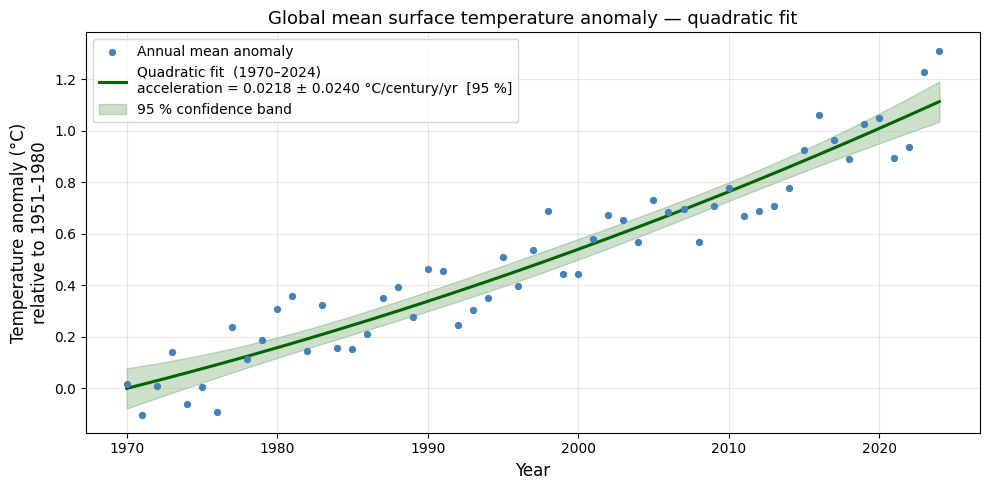

In [8]:
# ── Figure 2 — annual anomalies + quadratic fit ───────────────────────────
years_fine = np.linspace(years[0], years[-1], 300)
t_c_fine   = years_fine - t0
T_quad     = a * t_c_fine**2 + b * t_c_fine + c

# 95 % prediction band for the quadratic fit
# Var[T_fit] = [t²,t,1] * cov * [t²,t,1]^T
X_design  = np.column_stack([t_c_fine**2, t_c_fine, np.ones_like(t_c_fine)])
var_fit   = np.einsum("ij,jk,ik->i", X_design, cov_matrix, X_design)
ci95_band = 1.96 * np.sqrt(var_fit)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(years, T, s=18, color="steelblue", zorder=3, label="Annual mean anomaly")
ax.plot(years_fine, T_quad, lw=2.2, color="darkgreen",
        label=f"Quadratic fit  ({years[0]}–{years[-1]})\n"
              f"acceleration = {acceleration*100:.4f} ± {acceleration_err*1.96*100:.4f} °C/century/yr  [95 %]")
ax.fill_between(years_fine, T_quad - ci95_band, T_quad + ci95_band,
                alpha=0.2, color="darkgreen", label="95 % confidence band")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Temperature anomaly (°C)\nrelative to 1951–1980", fontsize=12)
ax.set_title("Global mean surface temperature anomaly — quadratic fit", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Q2_quadratic_fit.png", dpi=150)
plt.show()

In [9]:
# ── Summary table ─────────────────────────────────────────────────────────
print("=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"\nLinear segment trends (OLS, 95 % CI via t-distribution)\n")
print(f"  1970–1997 :  {r1.slope*10:.3f} ± {ci1*10:.3f}  °C / decade  (R² = {r1.rvalue**2:.3f})")
print(f"  1998–2024 :  {r2.slope*10:.3f} ± {ci2*10:.3f}  °C / decade  (R² = {r2.rvalue**2:.3f})")
delta_slope    = (r2.slope - r1.slope) * 10
delta_slope_se = np.sqrt((ci1/1.96)**2 + (ci2/1.96)**2) * 10 * 1.96   # 95 % on difference
print(f"\n  Difference (P2 − P1) = {delta_slope:+.3f} ± {delta_slope_se:.3f}  °C / decade  [95 %]")
print()
print(f"Quadratic fit  1970–2024  (centred at {t0:.0f})\n")
print(f"  Acceleration (2a) = {acceleration*100:.4f} ± {acceleration_err*1.96*100:.4f}  °C/century/yr  [95 %]")
print(f"  p-value for curvature: {p_val:.4f}")
print("=" * 65)

SUMMARY

Linear segment trends (OLS, 95 % CI via t-distribution)

  1970–1997 :  0.185 ± 0.048  °C / decade  (R² = 0.706)
  1998–2024 :  0.240 ± 0.055  °C / decade  (R² = 0.767)

  Difference (P2 − P1) = +0.055 ± 0.073  °C / decade  [95 %]

Quadratic fit  1970–2024  (centred at 1997)

  Acceleration (2a) = 0.0218 ± 0.0240  °C/century/yr  [95 %]
  p-value for curvature: 0.0802


## Discussion

### Do the two linear segments indicate different forced-warming rates?

The OLS slope for 1998–2024 is numerically *larger* than for 1970–1997 (see summary table), suggesting the recent period has warmed faster per decade.  However, a difference in segment slopes does **not** necessarily imply a genuine change in the forced warming rate, for several reasons:

* **Internal variability** — ENSO, the Atlantic Multidecadal Oscillation and the Pacific Decadal Oscillation superimpose multi-year to multi-decadal swings of ±0.1–0.2 °C on top of the forced signal.  The 1997/98 El Niño created an elevated baseline for the "late" period; the 2016 and 2023 El Niños push its OLS slope upward.
* **Aerosol forcing** — a reduction in industrial sulfate aerosol emissions since the 1980s–1990s removes a cooling influence, which would *genuinely* accelerate the net forced warming; this is a real physical effect, not merely internal noise.
* **Confidence-interval overlap** — if the 95 % confidence intervals on the two slopes overlap, the apparent difference is not statistically distinguishable from zero.

### Quadratic fit: acceleration and physical meaning

The quadratic model fitted over **1970–2024** (centred at 1997) gives

$$T(t) = a\,(t-1997)^2 + b\,(t-1997) + c$$

The **acceleration** is $2a$ (the constant second derivative of the fitted curve).  

* **Positive sign** means the rate of warming *increased* over the 55-year window: early decades warmed more slowly than later decades.  
* **Size** — expressed in °C per century per year, it quantifies how much extra warming (in °C/yr) accumulates per additional year.  A value of order 0.001 °C yr⁻² means the warming rate grew by roughly 0.1 °C/decade per decade, consistent with a transition from ~0.15 °C/decade in the 1970s–80s to ~0.25–0.30 °C/decade in the 2010s–20s.

### Important caveat

The quadratic is used here purely as a **phenomenological curve** to test for statistically detectable curvature in the observational record.  Global temperature is *not* physically expected to follow a quadratic trajectory: forcing trajectories are scenario-dependent, climate feedbacks are non-linear, and internal variability is stochastic.  The significance of $a$ tells us only that the record is inconsistent with a perfectly linear trend over this period — it does not allow extrapolation or mechanistic attribution.